# Word Embedding Models, day 2 #

## Setup

Last class we built a word embedding model of Yelp reviews from Atlanta restaurants. Rather than spend today re-doing that work, we're going to **load a word2vec model that has already been trained on that corpus** and go straight to using it.

Run the two cells below, then we'll start playing.

In [ ]:
# install and import what we need
!pip install gensim gdown -q

import gensim
import gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 26.3 MB/s eta 0:00:00


### Where this model came from

The model you're about to load, `atl_reviews_model`, was built from the same
`Atlanta-random.jsonl` file we used last class. The steps were:

1. Read the reviews out of the JSON file and pull the text of each one.
2. Strip out the stray HTML tags with `BeautifulSoup`.
3. Lowercase everything, then split each review into sentences (`nltk`'s
   `sent_tokenize`) and each sentence into words (`TreebankWordTokenizer`),
   since word2vec expects an *iterable of iterables* — a list of sentences,
   each of which is a list of words.
4. Train, with a single call:

```python
atl_reviews_model = gensim.models.Word2Vec(
    sentences,
    min_count=2,      # ignore words that appear only once
    vector_size=100,  # each word becomes a 100-dimensional vector
    workers=5)        # parallel processing
```

`gensim.models.Word2Vec()` takes a couple dozen parameters. Only `sentences` is
truly required, but these are the ones worth knowing:

| Parameter | What it does |
|---|---|
| `sentences` | Your data, as an iterable of iterables. |
| `vector_size` | How many dimensions each word vector gets. Bigger corpora can support 100–300. (Called `size` in older versions of gensim.) |
| `sg` | Training algorithm: `1` for skip-gram, otherwise the default CBOW. |
| `window` | How many words of context on either side to train on. Smaller windows tend to capture semantic meaning better. |
| `min_count` | Frequency threshold — words rarer than this are ignored, since they're hard to train. |
| `epochs` | Passes over the corpus. Default is 5; more takes longer and risks overfitting. |
| `alpha` | Learning rate. |
| `seed` | Random seed, so you can reproduce a run exactly. |

Training that model took a few minutes, so it was saved to disk with
`atl_reviews_model.save('atl_reviews_model')` and uploaded to Google Drive. The
next cell downloads it and loads it back in — which takes seconds.

In [ ]:
# Download the pretrained model from Google Drive.
#
# NOTE: This is the single file produced by `model.save()`, uploaded to
# LK's Google Drive with sharing set to "Anyone with the link." The ID is the part of the
# share URL between /d/ and /view. If you ever retrain with a much larger
# vocabulary, gensim will split the model into extra .npy sidecar files — in
# that case, zip them all together and unzip after downloading.

FILE_ID = "1D1UlhwjKB-pXy4MjPuXH0pFGBnnWE1UF"

gdown.download(f"https://drive.google.com/uc?export=download&id={FILE_ID}",
               "atl_reviews_model", quiet=False)

# load it back in
atl_reviews_model = gensim.models.Word2Vec.load('atl_reviews_model')

# quick check that everything arrived in one piece
print(f"Words in the model: {len(atl_reviews_model.wv):,}")
print(f"Dimensions per vector: {atl_reviews_model.wv.vector_size}")
print(f"\nMost frequent words: {', '.join(atl_reviews_model.wv.index_to_key[:20])}")

Downloading...
From: https://drive.google.com/uc?export=download&id=1D1UlhwjKB-pXy4MjPuXH0pFGBnnWE1UF
To: /content/atl_reviews_model
100%|██████████| 19.2M/19.2M [00:00<00:00, 30.4MB/s]


Words in the model: 23,187
Dimensions per vector: 100

Most frequent words: ., the, and, ,, i, a, to, was, it, !, of, is, for, in, my, this, that, but, they, food


Every word in that vocabulary now has a 100-dimensional vector attached to it.
You can see one for yourself:

In [ ]:
word_of_interest = "coffee"

print(f"Row number (index): {atl_reviews_model.wv.key_to_index[word_of_interest]}")
print(f"Word vector: {atl_reviews_model.wv[word_of_interest]}")

Row number (index): 299
Word vector: [-2.6068492   1.7936336  -1.9038206  -0.06713856  0.18326768  0.601788
  2.2531574   2.0485284  -0.7037475  -1.4095904  -0.45563632 -0.61822873
  2.1231866   0.12689467  0.4383235   0.6782597   1.8207351   0.6318391
  0.7012789   1.4304422  -0.50731176 -0.07622872 -1.2158843   0.24799915
  0.6948051  -0.76369745 -1.0878367   2.1880102  -0.6443321   1.3105487
 -0.37222412 -0.13053106 -0.80101806  1.4485474  -0.26525238  0.4891762
 -1.189477   -0.628973   -1.127119    0.45043308 -0.18217635  0.9649679
 -0.5313222  -0.9410246   2.0249794  -1.1780388   0.2093496  -0.41840622
  0.0297237   1.0589222   0.52460647 -0.53049064 -1.6384102   0.31080392
 -0.6599763   0.5580603   2.285893   -0.8819268   0.02537959  0.47129977
 -0.77382004  0.2690066   1.1332638  -0.83410007 -1.9398111   0.42246455
 -1.9561083  -0.25616324  0.18723053  0.06649577 -2.4114504   0.50451005
  1.5959492  -0.7665798  -0.8362922   0.6013705   0.7954242   1.0191228
  0.12435178 -0.86329

## Similarity

Here's where we left off last class:

word2vec can tell us which words, according to its model, are most similar to any other. We call `model.wv.most_similar("word", topn=number of similar words)`. Let's try "delicious."

In [ ]:
# basic similarity w/ nouns
atl_reviews_model.wv.most_similar("coffee", topn=10)

[('tea', 0.6979807019233704),
 ('beer', 0.667573094367981),
 ('latte', 0.6645841002464294),
 ('brew', 0.6421772241592407),
 ('teas', 0.6367108225822449),
 ('lemonade', 0.6294706463813782),
 ('iced', 0.6200300455093384),
 ('smoothie', 0.6034059524536133),
 ('soda', 0.6005473136901855),
 ('margarita', 0.6004281640052795)]

In [ ]:
# basic similarity w/ nouns
atl_reviews_model.wv.most_similar("fries", topn=10)

[('tots', 0.7386356592178345),
 ('chips', 0.7137103080749512),
 ('wings', 0.7057610154151917),
 ('nachos', 0.6544098258018494),
 ('pickles', 0.6438120007514954),
 ('toast', 0.6425278782844543),
 ('pancakes', 0.6360273361206055),
 ('plantains', 0.6304255127906799),
 ('biscuits', 0.6259104609489441),
 ('nuggets', 0.6246064901351929)]

In [ ]:
# basic similarity w/ adjectives
atl_reviews_model.wv.most_similar("gross", topn=10)

[('bland', 0.7723342776298523),
 ('fishy', 0.7383384108543396),
 ('disgusting', 0.7332894802093506),
 ('bitter', 0.7306501865386963),
 ('flavorless', 0.7178993225097656),
 ('alright', 0.7168023586273193),
 ('mushy', 0.716484546661377),
 ('burnt', 0.7066535949707031),
 ('blah', 0.7062119245529175),
 ('meh', 0.7001880407333374)]

### Similarity between two words

We can also choose specific words to compare, with similarity reported as cosine similarity.

As discussed, identical vectors will have a score of 1. Totally unrelated vectors will have scores close to 0, meaning that they are *orthogonal*.

In [ ]:
# similarity b/t two words

print(atl_reviews_model.wv.similarity(w1="soup",w2="delicious"))
print(atl_reviews_model.wv.similarity(w1="soup",w2="disgusting"))

0.27376607
0.040868588


## Pretrained models

One of the nice things about vector models (and many language models, including LLMs, is that they can be pretrained and saved, and then made more widely available, so that you don't need to re-train your model each time from scratch. There are also other reasons why pretrained models are helpful or desirable. What are some other reasons that you can think of?

`gensim` makes a bunch of pretrained models available for download. You can see what's in the current list like so:

In [ ]:
import gensim.downloader
for model_name in gensim.downloader.info()['models'].keys():
    print(model_name)

fasttext-wiki-news-subwords-300
conceptnet-numberbatch-17-06-300
word2vec-ruscorpora-300
word2vec-google-news-300
glove-wiki-gigaword-50
glove-wiki-gigaword-100
glove-wiki-gigaword-200
glove-wiki-gigaword-300
glove-twitter-25
glove-twitter-50
glove-twitter-100
glove-twitter-200
__testing_word2vec-matrix-synopsis


Let's pick `glove-wiki-gigaword-100`. The [GloVe](https://nlp.stanford.edu/projects/glove/) project stands for Global Vectors for Word Representations, rn by a team at Stanford. This particular model was trained on a dump of Wikipedia from 2014, and Gigaword 5th Edition, which is a large dataset of English newswire text compiled from sources like the Associated Press and The New York Times. There are about 6 billion tokens, but each vector has only 100 dimensions, just like our Atlanta reviews model.

While it is downloading, I am going to give you a quick lecture on [this research paper](https://aclanthology.org/N13-1090/) and [this one](https://gargnikhil.com/files/pdfs/GSJZ18_embedstereotypes.pdf), and a few more interesting things about vectors that they popularized.

In [ ]:
## download glove-wiki-gigaword-100

glove_vectors = gensim.downloader.load('glove-wiki-gigaword-100')

[==================================================] 100.0% 128.1/128.1MB downloaded


## Similarlity with a pretrained model

In [ ]:
# almost the same as our model, except withou the '.wv' in the middle
# because what we've downloaded is not the whole model, but rather just
# the vectors
glove_vectors.most_similar("delicious", topn=10)

[('tasty', 0.862883985042572),
 ('spicy', 0.7911790609359741),
 ('dessert', 0.7600688338279724),
 ('savory', 0.7334800362586975),
 ('refreshing', 0.7245498299598694),
 ('flavor', 0.7094911336898804),
 ('desserts', 0.7085403203964233),
 ('delightful', 0.7065228223800659),
 ('flavorful', 0.7050559520721436),
 ('baked', 0.7047907114028931)]

## Similarity between two words

As above, very similar to before, except no `.wv` in the middle:

In [ ]:
# similarity b/t two words

print(glove_vectors.similarity(w1="soup",w2="delicious"))
print(glove_vectors.similarity(w1="soup",w2="disgusting"))

0.61600333
0.16731495


Comprehension check: Why are these numbers different than the ones we got before?

### Analogy

Here we go! As explained in the mini-lecture, because vectors can be added and subtracted from each other, we can set up analogies. The most commonly seen example is:

'Man is to King as Woman is to ____?'

We can implement this method with a built-in function. The signs come straight out of the arithmetic. `positive` and `negative` are just labels for which vectors get added and which get subtracted:

`king - man + woman`

The order of the terms as they are written can be a little confusing, so another way to understand this is as a journey through the vector space. Start at **king**. Subtract **man** — you strip out whatever makes king male, leaving something like "royalty, gender removed." Add **woman** — you put a gender back in, but the other one. Where you land is near **queen**.

So the sign of each word is determined by which side of the analogy it sits on, not by anything about the word itself:

Here it is a chart of the same thing:

| Word | Role in the analogy | Sign |
|---|---|---|
| `man` | the term you're moving **away** from | negative |
| `woman` | the term you're moving **toward** | positive |
| `king` | the starting point you're transforming | positive |

In [ ]:
# analogies
# format is: "man is to king as woman is to ???"

results = glove_vectors.most_similar(positive=['woman', 'king'],
                                     negative=['man'],
                                     topn=10)

for word, score in results:
    print(f"{word}: {score:.4f}")

queen: 0.7699
monarch: 0.6843
throne: 0.6756
daughter: 0.6595
princess: 0.6521
prince: 0.6517
elizabeth: 0.6465
mother: 0.6312
emperor: 0.6106
wife: 0.6099


## Exercise:

**Use the code below, swapping out the relevant words, to see if you can replicate some of the findings from the "Stereotypes" paper.**

In [ ]:
# analogies
# format is: "man is to king as woman is to ???"

results = glove_vectors.most_similar(positive=['woman', 'king'],
                                     negative=['man'],
                                     topn=10)

for word, score in results:
    print(f"{word}: {score:.4f}")

## BONUS: Visualization!

Find below some code you can use to make visualizations from your word2vec model. We can't visualize all the many dimensions in our model, so we need to reduce them to two dimensions for our meager human brains. We do that with something called principal component analysis (PCA).

Don't worry about the details for now. This is just a fun way to take a look at the output of our model.

**Remember**: Our visualization reduces MANY dimensions to two, so a lot of information is lost.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_pca(model, words, fit_on="vocab", vocab_size=2000, title=None):
    """Plot words in 2D via PCA.

    fit_on="selection" : fit PCA on selected words
    fit_on="vocab"     : fit PCA on the most frequent words, then project these in
    """
    missing = [w for w in words if w not in model.wv]
    words = [w for w in words if w in model.wv]
    if missing:
        print("Not in the model, skipped: " + ", ".join(missing))
    if len(words) < 3:
        print("Need at least 3 words that are in the model.")
        return

    word_vectors = np.array([model.wv[w] for w in words])

    pca = PCA(n_components=2)
    if fit_on == "vocab":
        background = np.array([model.wv[w] for w in model.wv.index_to_key[:vocab_size]])
        pca.fit(background)
        twodim = pca.transform(word_vectors)
    else:
        twodim = pca.fit_transform(word_vectors)

    var = pca.explained_variance_ratio_

    plt.figure(figsize=(7, 7))
    plt.scatter(twodim[:, 0], twodim[:, 1], edgecolors='k', c='r')
    for word, (x, y) in zip(words, twodim):
        plt.text(x + 0.02, y + 0.02, word)
    plt.xlabel(f"PC1 — {var[0]:.0%} of variance")
    plt.ylabel(f"PC2 — {var[1]:.0%} of variance")
    plt.title(title or f"PCA fit on: {fit_on}")
    plt.show()

    print(f"These two dimensions capture {var.sum():.0%} of the variation. "
          f"The other {1 - var.sum():.0%} is not on this plot.")

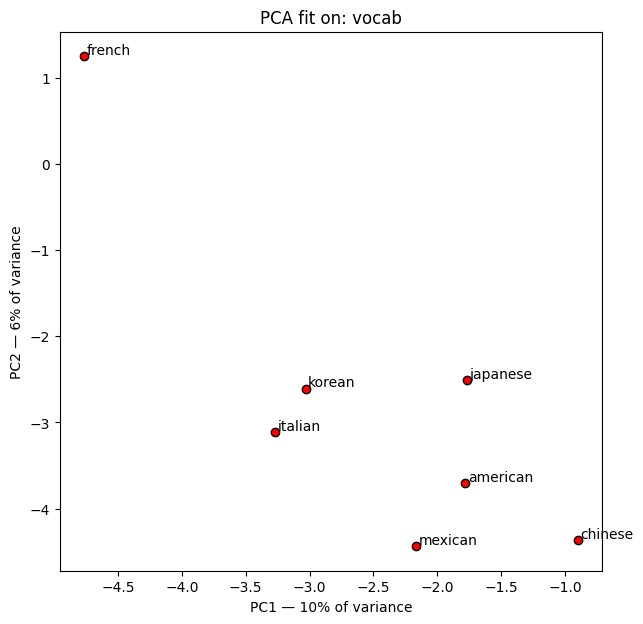

These two dimensions capture 15% of the variation. The other 85% is not on this plot.


In [ ]:
cuisines = ['italian','french','american','korean','japanese','mexican','chinese']

# the fixed coordinate system: the whole vocabulary defines the space
plot_pca(atl_reviews_model, cuisines, fit_on="vocab")

## Let the model choose the words

Hand-picking words means you only ever see what you already thought to look for. A more exploratory move is to pick one word and plot its nearest neighbors.

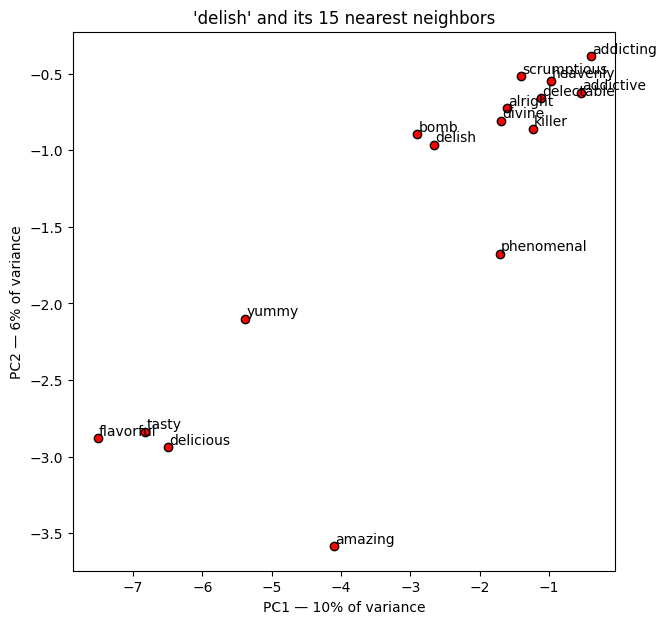

These two dimensions capture 15% of the variation. The other 85% is not on this plot.


In [ ]:
def plot_neighborhood(model, word, topn=15):
    if word not in model.wv:
        print(f"'{word}' is not in the model.")
        return
    neighbors = [w for w, score in model.wv.most_similar(word, topn=topn)]
    plot_pca(model, [word] + neighbors, fit_on="vocab",
             title=f"'{word}' and its {topn} nearest neighbors")

plot_neighborhood(atl_reviews_model, "delish")

### Axes that mean something

Rather than letting PCA pick the directions, we can **build our own axes out of word pairs** — the same arithmetic behind the analogies we did earlier.

Take `delicious - disgusting`. That difference is a direction in the vector
space, and it points from one pole of sentiment toward the other. Any word can
be projected onto it, giving a single number: how far toward "delicious" does
this word sit? Do that with two different axes and you have a plot whose x and y
you can actually name.

Two refinements make this work better in practice:

- **Use several words per pole, not one.** A single word carries its own quirks;
  averaging four or five of them isolates the shared direction. This is the
  approach in [SemAxis](https://aclanthology.org/P18-1228/) (An, Kwak, and Ahn,
  ACL 2018), which builds hundreds of such axes from antonym pairs. We'll see this paper cited again in the next lecture.
- **Subtract the mean vector first.** Word2vec vectors all share a large common
  component, which drags every score toward the same value. Removing it spreads
  the words out.

In [ ]:
def make_axis(model, positive, negative):
    """Build a named direction from two sets of pole words."""
    mean_vec = model.wv.vectors.mean(axis=0)
    pos = [w for w in positive if w in model.wv]
    neg = [w for w in negative if w in model.wv]
    if not pos or not neg:
        raise ValueError("Each pole needs at least one word that's in the model.")
    p = np.mean([model.wv[w] for w in pos], axis=0) - mean_vec
    n = np.mean([model.wv[w] for w in neg], axis=0) - mean_vec
    axis = p - n
    return axis / np.linalg.norm(axis)

def score_on_axis(model, word, axis):
    """How far along the axis does this word sit? Runs -1 to 1."""
    v = model.wv[word] - model.wv.vectors.mean(axis=0)
    return float(np.dot(v / np.linalg.norm(v), axis))

def plot_semantic_axes(model, words, x_axis, y_axis, x_label, y_label, title=None):
    missing = [w for w in words if w not in model.wv]
    words = [w for w in words if w in model.wv]
    if missing:
        print("Not in the model, skipped: " + ", ".join(missing))
    if not words:
        return

    xs = [score_on_axis(model, w, x_axis) for w in words]
    ys = [score_on_axis(model, w, y_axis) for w in words]

    plt.figure(figsize=(9, 9))
    plt.scatter(xs, ys, edgecolors='k', c='r')
    for w, x, y in zip(words, xs, ys):
        plt.text(x + 0.005, y + 0.005, w)
    plt.axhline(0, color='gray', lw=0.8)
    plt.axvline(0, color='gray', lw=0.8)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title or "Words on two semantic axes")
    plt.show()

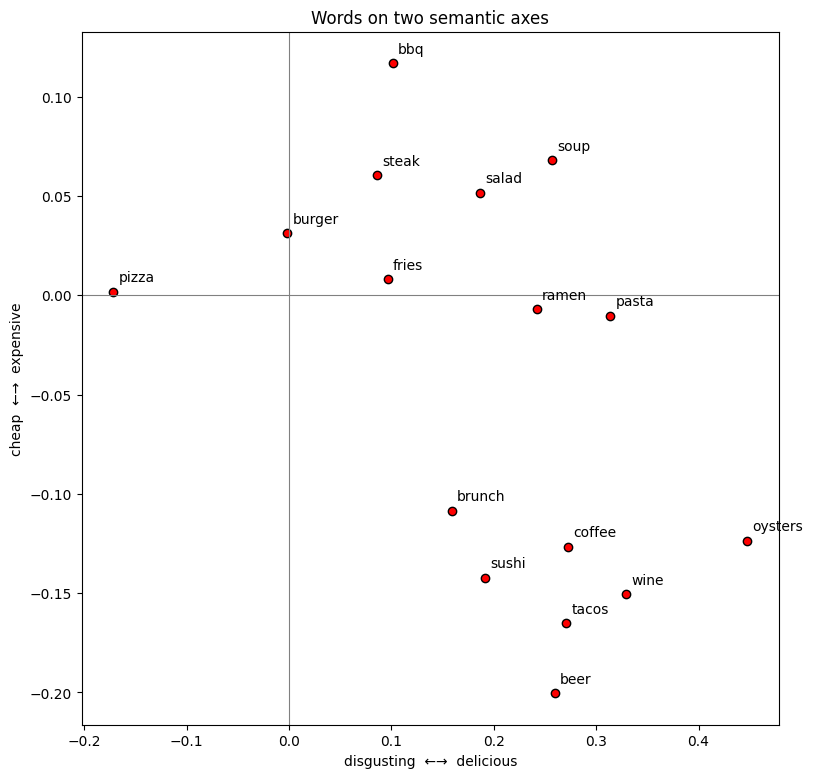

In [ ]:
# define two axes we can actually name
sentiment_axis = make_axis(atl_reviews_model,
                           positive=['delicious','amazing','tasty','excellent'],
                           negative=['bland','disgusting','terrible','awful'])

price_axis = make_axis(atl_reviews_model,
                       positive=['expensive','pricey','overpriced','upscale'],
                       negative=['cheap','affordable','inexpensive','reasonable'])

# and place some words on them
words_to_plot = ['coffee','fries','soup','pasta','tacos','sushi','burger','salad',
                 'pizza','ramen','steak','oysters','wine','beer','brunch','bbq']

plot_semantic_axes(atl_reviews_model, words_to_plot,
                   sentiment_axis, price_axis,
                   x_label="disgusting  ←→  delicious",
                   y_label="cheap  ←→  expensive")

Now the position of each word means something concrete: this model, trained on these reviews, associates pizza with disguisting and bbq with expensive. Atlanta!!!

## Exercise:

**Invent your own axes and plot something.** Some starting points:

- `authentic ←→ fusion` against `cheap ←→ expensive` — where does each cuisine land?
- `service ←→ food` — do reviewers talk about some restaurants in terms of one
  and not the other?
- Build one axis from `fast, quick, efficient` vs. `slow, waited, forever` and
  see which foods sit at each end.

Then compare against `glove_vectors`: does the general-purpose model place these
words the same way our Atlanta reviews model does? (Note that GloVe has no `.wv`, so you'd need to adjust the functions above.)


*Lauren F. Klein wrote version 1.0 of this notebook in 2019 based on the [Advanced Topics in Word Vectors workshop](https://dh2018.adho.org/en/machine-reading-part-ii-advanced-topics-in-word-vectors/) at DH 2018 as well as tutorials by [Radim Rehurek](https://rare-technologies.com/word2vec-tutorial/) and [Chris McCormick](http://mccormickml.com/2016/04/19/word2vec-tutorial-the-skip-gram-model/) and class notebooks by Sandeep Soni and Maria Antoniak. It was updated again in 2021, 2022, 2024, and 2026.*